In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Admin\anaconda3\envs\houseprice\python.exe
3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:26:47) [MSC v.1942 64 bit (AMD64)]


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/Housing.csv")


In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.shape

(545, 13)

In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

In [12]:
for column in df.select_dtypes(include='str').columns:
    print(f"\n{column}:")
    print(df[column].unique())


mainroad:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

guestroom:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

basement:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

hotwaterheating:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

airconditioning:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

prefarea:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

furnishingstatus:
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


In [13]:
plt.hist(df['price'])

NameError: name 'plt' is not defined

In [14]:
import matplotlib.pyplot as plt

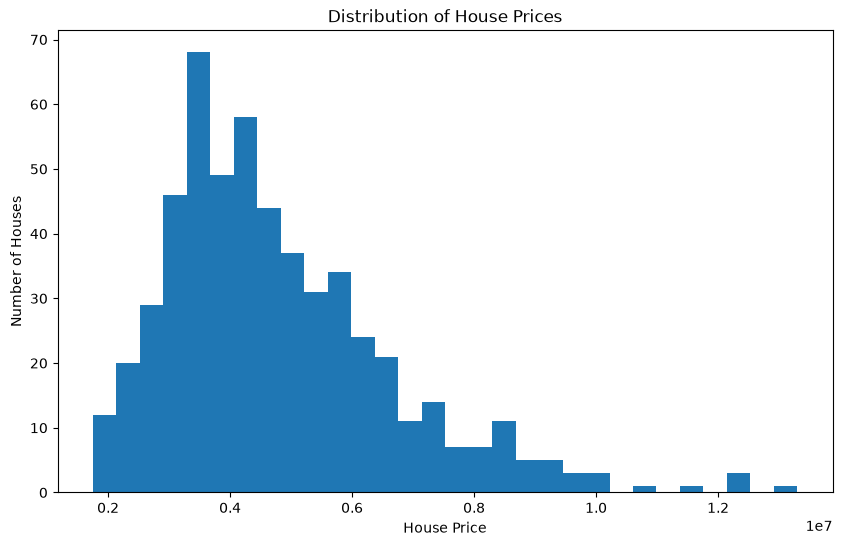

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30)
plt.xlabel('House Price')
plt.ylabel('Number of Houses')
plt.title('Distribution of House Prices')
plt.show()

The house price distribution is right-skewed, with most houses having relatively moderate prices and a smaller number of houses having substantially higher prices.


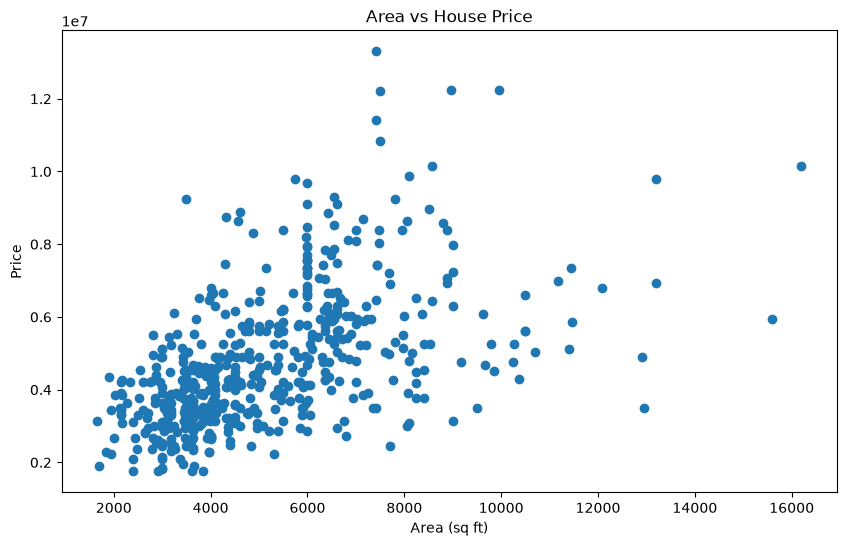

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df['area'], df['price'])
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('Area vs House Price')
plt.show()

There is a positive relationship between area and house price. Larger houses generally tend to have higher prices, although other factors also contribute to price variation.

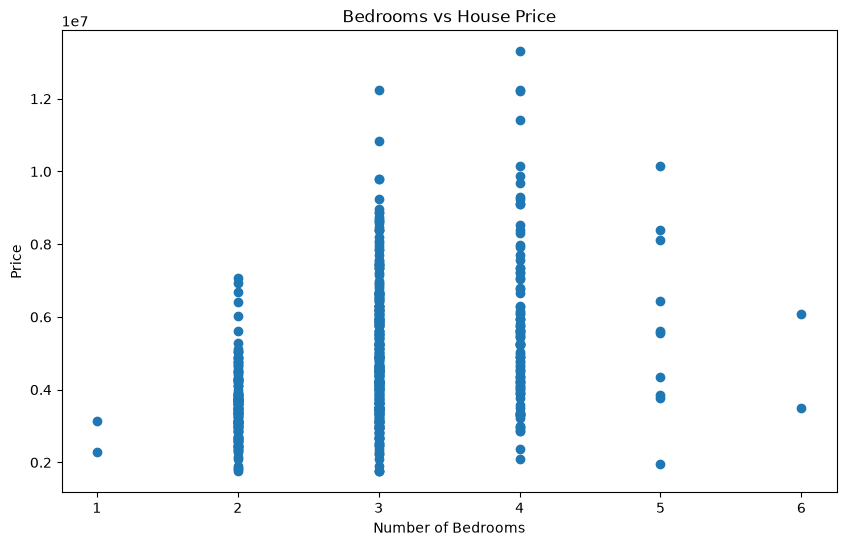

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df['bedrooms'], df['price'])
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.title('Bedrooms vs House Price')
plt.show()

House prices vary across different numbers of bedrooms. Although houses with more bedrooms can have higher prices, there is considerable overlap between the price ranges, indicating that bedroom count alone is not sufficient to determine house price.

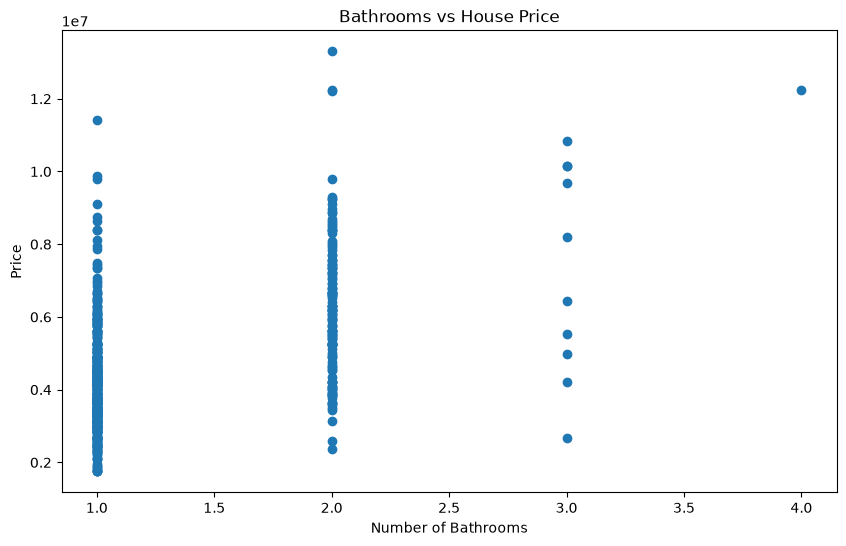

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df['bathrooms'], df['price'])
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price')
plt.title('Bathrooms vs House Price')
plt.show()

Most houses have one or two bathrooms. Houses with more bathrooms generally show higher potential prices, but bathroom count alone does not fully explain house price variation.

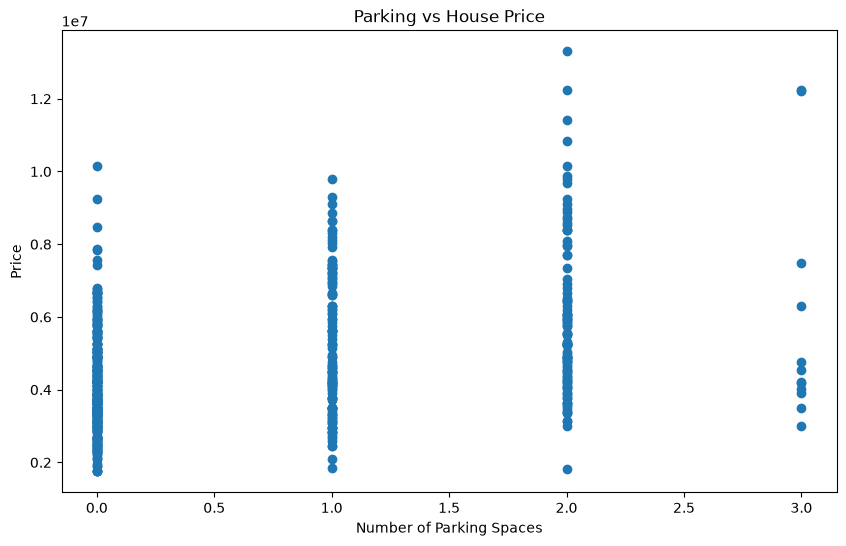

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df['parking'], df['price'])
plt.xlabel('Number of Parking Spaces')
plt.ylabel('Price')
plt.title('Parking vs House Price')
plt.show()

Houses with greater parking capacity tend to include higher-priced properties. However, the wide variation within each group indicates that parking is only one of several factors affecting house prices.

In [20]:
df.groupby('mainroad')['price'].mean()

mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64

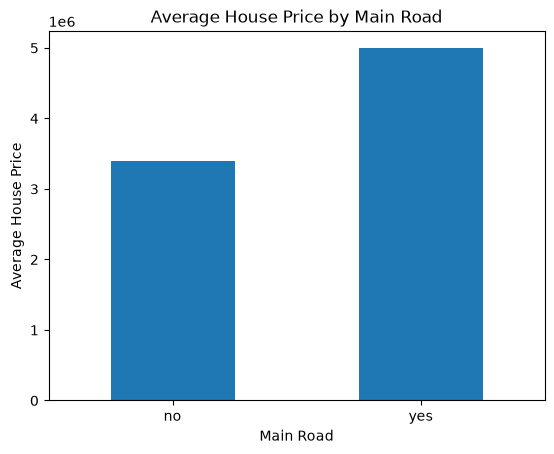

In [21]:
df.groupby('mainroad')['price'].mean().plot(kind='bar')
plt.xlabel('Main Road')
plt.ylabel('Average House Price')
plt.title('Average House Price by Main Road')
plt.xticks(rotation=0)
plt.show()

Houses connected to the main road have a higher average price than houses that are not connected to the main road. This indicates that main-road accessibility may have a positive influence on house prices.

In [22]:
df.groupby('guestroom')['price'].mean()

guestroom
no     4.544546e+06
yes    5.792897e+06
Name: price, dtype: float64

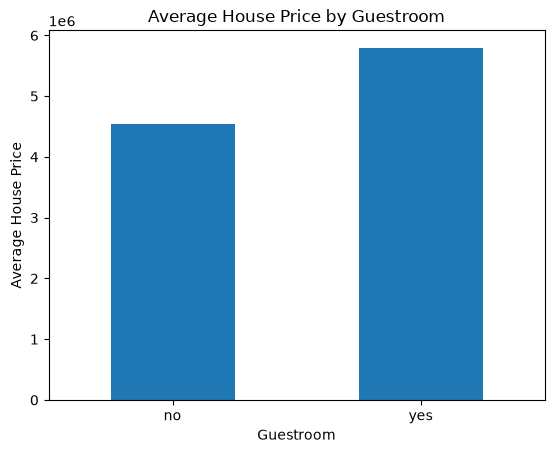

In [23]:
df.groupby('guestroom')['price'].mean().plot(kind='bar')
plt.xlabel('Guestroom')
plt.ylabel('Average House Price')
plt.title('Average House Price by Guestroom')
plt.xticks(rotation=0)
plt.show()

Houses with guestrooms have a higher average price than houses without guestrooms. This suggests that the availability of a guestroom may positively influence house prices.

In [24]:
df.groupby('basement')['price'].mean()

basement
no     4.509966e+06
yes    5.242615e+06
Name: price, dtype: float64

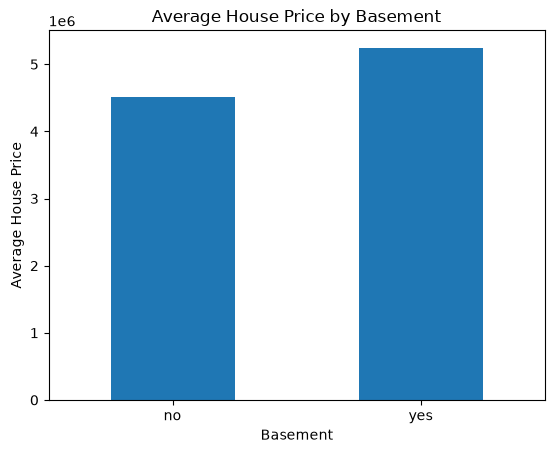

In [25]:
df.groupby('basement')['price'].mean().plot(kind='bar')
plt.xlabel('Basement')
plt.ylabel('Average House Price')
plt.title('Average House Price by Basement')
plt.xticks(rotation=0)
plt.show()

Houses with basements have a higher average price than houses without basements. This indicates that the presence of a basement may positively influence house prices.

In [26]:
df.groupby('hotwaterheating')['price'].mean()

hotwaterheating
no     4.728593e+06
yes    5.559960e+06
Name: price, dtype: float64

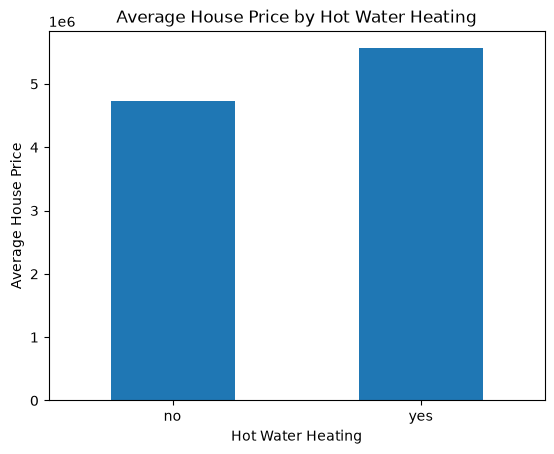

In [27]:
df.groupby('hotwaterheating')['price'].mean().plot(kind='bar')
plt.xlabel('Hot Water Heating')
plt.ylabel('Average House Price')
plt.title('Average House Price by Hot Water Heating')
plt.xticks(rotation=0)
plt.show()

Houses with hot water heating have a higher average price than houses without hot water heating. This suggests that the availability of hot water heating may positively influence house prices.

In [28]:
df.groupby('airconditioning')['price'].mean()


airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64

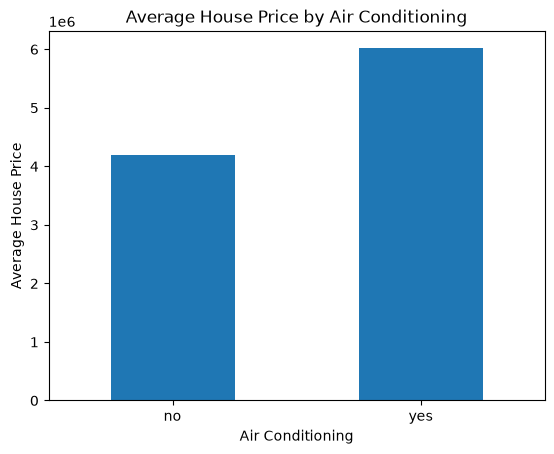

In [29]:
df.groupby('airconditioning')['price'].mean().plot(kind='bar')
plt.xlabel('Air Conditioning')
plt.ylabel('Average House Price')
plt.title('Average House Price by Air Conditioning')
plt.xticks(rotation=0)
plt.show()

Houses with air conditioning have a substantially higher average price than houses without air conditioning. This indicates that air conditioning is an important feature associated with higher house prices in the dataset.

In [30]:
df.groupby('prefarea')['price'].mean()

prefarea
no     4.425299e+06
yes    5.879046e+06
Name: price, dtype: float64

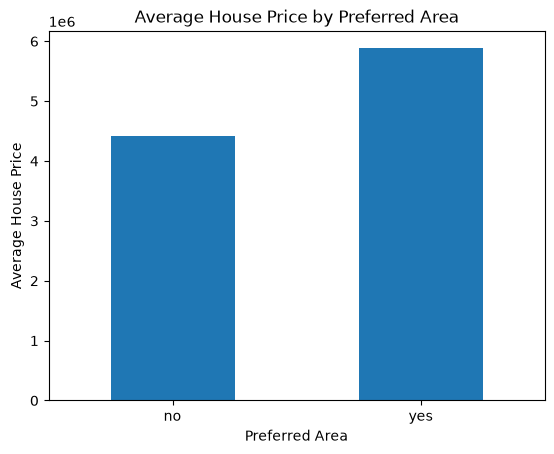

In [31]:
df.groupby('prefarea')['price'].mean().plot(kind='bar')
plt.xlabel('Preferred Area')
plt.ylabel('Average House Price')
plt.title('Average House Price by Preferred Area')
plt.xticks(rotation=0)
plt.show()

Houses located in preferred areas have a higher average price than houses outside preferred areas. This indicates that location preference may have a positive influence on house prices.

In [32]:
df.groupby('furnishingstatus')['price'].mean()

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

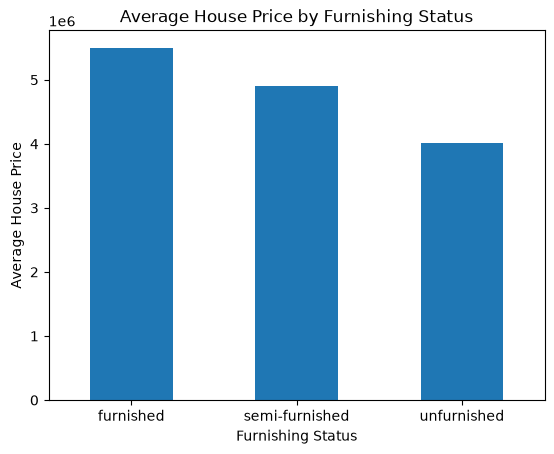

In [33]:
df.groupby('furnishingstatus')['price'].mean().plot(kind='bar')
plt.xlabel('Furnishing Status')
plt.ylabel('Average House Price')
plt.title('Average House Price by Furnishing Status')
plt.xticks(rotation=0)
plt.show()

Furnished houses have the highest average price, followed by semi-furnished and unfurnished houses. This indicates a positive association between furnishing status and house prices, with furnished properties generally commanding higher prices.

In [34]:
numeric_df = df.select_dtypes(include='number')
numeric_df.head()

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


In [35]:
correlation = numeric_df.corr()
correlation

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


In [36]:
correlation['price'].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

ModuleNotFoundError: No module named 'seaborn'

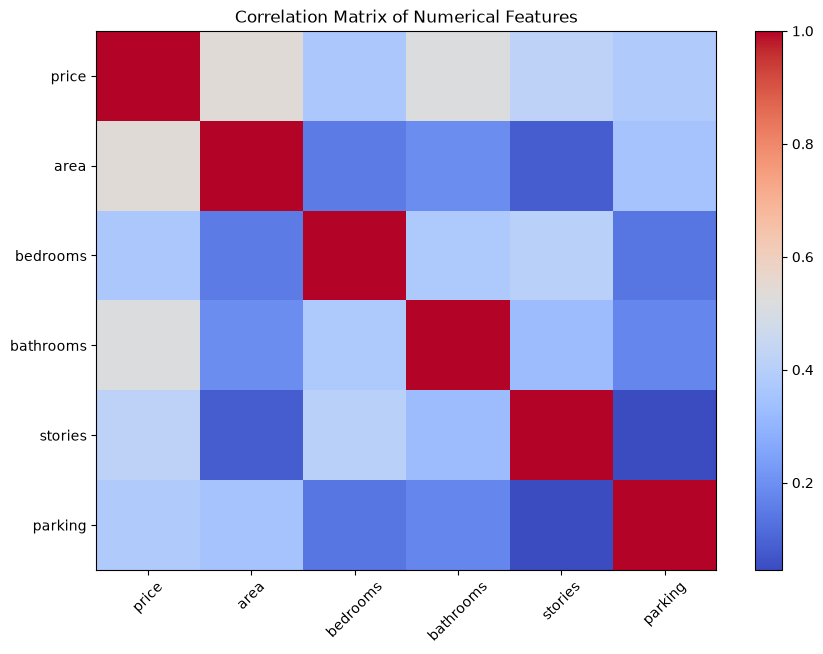

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [39]:
numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

In [40]:
correlation['price'].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

In [41]:
numeric_df = df.select_dtypes(include='number')

In [42]:
correlation = numeric_df.corr()
correlation

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


In [43]:
correlation['price'].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

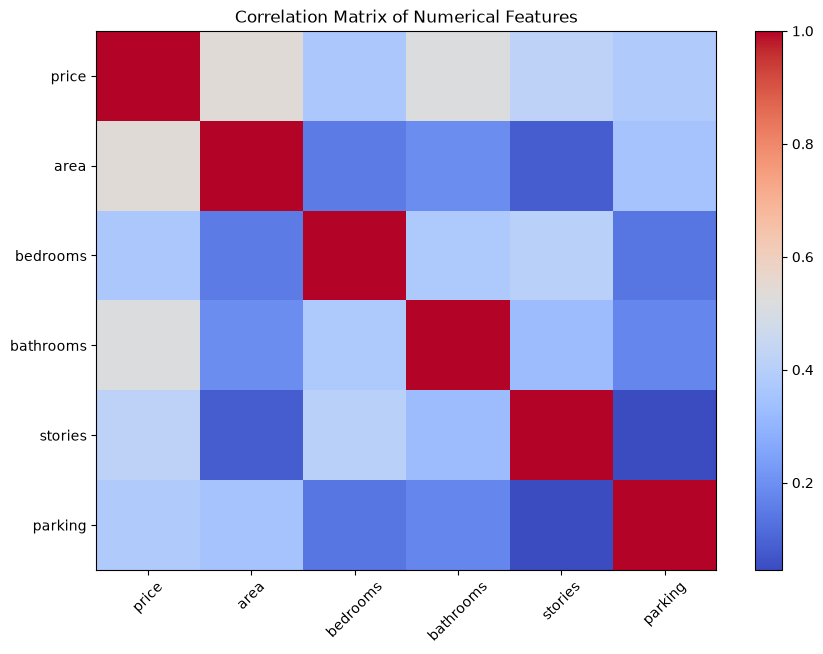

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [45]:
correlation['price'].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

The correlation analysis shows that area has the strongest positive relationship with house price among the numerical features. Other features such as bathrooms, bedrooms, stories, and parking also show positive relationships, although their correlations are comparatively weaker. This indicates that multiple numerical features contribute to house price prediction.

In [46]:
X = df.drop('price', axis=1)
y = df['price']

In [47]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [48]:
X = df.drop('price', axis=1)

In [49]:
y = df['price']

In [50]:
X = df.drop('price', axis=1)
y = df['price']

In [51]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [52]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in binary_columns:
    X[column] = X[column].map({'no': 0, 'yes': 1})

In [53]:
X = pd.get_dummies(
    X,
    columns=['furnishingstatus'],
    drop_first=True
)

In [54]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [55]:
X.dtypes

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

In [56]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in binary_columns:
    X[column] = X[column].map({'no': 0, 'yes': 1})

In [57]:
X = pd.get_dummies(
    X,
    columns=['furnishingstatus'],
    drop_first=True
)

KeyError: "None of [Index(['furnishingstatus'], dtype='str')] are in the [columns]"

In [58]:
for column in binary_columns:
    X[column] = X[column].map({'no': 0, 'yes': 1})

In [59]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')

In [60]:
X = pd.get_dummies(
    X,
    columns=['furnishingstatus'],
    drop_first=True
)

KeyError: "None of [Index(['furnishingstatus'], dtype='str')] are in the [columns]"

In [61]:
print(X.columns)
print(X.dtypes)

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')
area                                 int64
bedrooms                             int64
bathrooms                            int64
stories                              int64
mainroad                           float64
guestroom                          float64
basement                           float64
hotwaterheating                    float64
airconditioning                    float64
parking                              int64
prefarea                           float64
furnishingstatus_semi-furnished       bool
furnishingstatus_unfurnished          bool
dtype: object


In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


In [65]:
from sklearn.preprocessing import StandardScaler

In [66]:
scaler = StandardScaler()

In [67]:
X_train_scaled = scaler.fit_transform(X_train)

c:\Users\Admin\anaconda3\envs\houseprice\Lib\site-packages\sklearn\utils\extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Admin\anaconda3\envs\houseprice\Lib\site-packages\sklearn\utils\extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Admin\anaconda3\envs\houseprice\Lib\site-packages\sklearn\utils\extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [68]:
X_test_scaled = scaler.transform(X_test)

In [69]:
scaler.fit_transform(X_train)

c:\Users\Admin\anaconda3\envs\houseprice\Lib\site-packages\sklearn\utils\extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Admin\anaconda3\envs\houseprice\Lib\site-packages\sklearn\utils\extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Admin\anaconda3\envs\houseprice\Lib\site-packages\sklearn\utils\extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


array([[ 0.38416819,  0.05527092,  1.53917323, ...,         nan,
        -0.870669  , -0.67690027],
       [ 0.9291807 ,  0.05527092,  1.53917323, ...,         nan,
         1.14854209, -0.67690027],
       [-0.60775457, -1.28351359, -0.5579503 , ...,         nan,
        -0.870669  , -0.67690027],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ...,         nan,
        -0.870669  , -0.67690027],
       [-0.5060189 , -1.28351359, -0.5579503 , ...,         nan,
        -0.870669  ,  1.47732249],
       [ 0.15707965,  0.05527092,  1.53917323, ...,         nan,
         1.14854209, -0.67690027]], shape=(436, 13))

In [70]:
scaler.transform(X_test)

array([[ 0.33875048,  1.39405543,  1.53917323, ...,         nan,
        -0.870669  ,  1.47732249],
       [ 0.61125674,  0.05527092,  1.53917323, ...,         nan,
        -0.870669  , -0.67690027],
       [-0.5060189 , -1.28351359, -0.5579503 , ...,         nan,
         1.14854209, -0.67690027],
       ...,
       [ 0.38416819,  1.39405543,  1.53917323, ...,         nan,
         1.14854209, -0.67690027],
       [ 0.38416819,  0.05527092,  1.53917323, ...,         nan,
         1.14854209, -0.67690027],
       [ 0.4295859 ,  0.05527092,  1.53917323, ...,         nan,
        -0.870669  , -0.67690027]], shape=(109, 13))

In [71]:
print("Original training shape:", X_train.shape)
print("Scaled training shape:", X_train_scaled.shape)

Original training shape: (436, 13)
Scaled training shape: (436, 13)


In [72]:
from sklearn.linear_model import LinearRegression

In [73]:
model_lr = LinearRegression()

In [74]:
model_lr.fit(X_train_scaled, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [75]:
X[column] = X[column].map({'no': 0, 'yes': 1})

In [76]:
X.isnull().sum()

area                                 0
bedrooms                             0
bathrooms                            0
stories                              0
mainroad                           545
guestroom                          545
basement                           545
hotwaterheating                    545
airconditioning                    545
parking                              0
prefarea                           545
furnishingstatus_semi-furnished      0
furnishingstatus_unfurnished         0
dtype: int64

In [77]:
X.isnull().sum()

area                                 0
bedrooms                             0
bathrooms                            0
stories                              0
mainroad                           545
guestroom                          545
basement                           545
hotwaterheating                    545
airconditioning                    545
parking                              0
prefarea                           545
furnishingstatus_semi-furnished      0
furnishingstatus_unfurnished         0
dtype: int64

In [78]:
X = df.drop('price', axis=1).copy()
y = df['price'].copy()

In [79]:
print(X['mainroad'].unique())

<StringArray>
['yes', 'no']
Length: 2, dtype: str


In [80]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in binary_columns:
    X[column] = (
        X[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'no': 0, 'yes': 1})
    )

In [81]:
X = pd.get_dummies(
    X,
    columns=['furnishingstatus'],
    drop_first=True
)

In [82]:
X.isnull().sum()

area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

In [83]:
X.isnull().sum()

area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (436, 13)
Scaled testing data: (109, 13)


In [88]:
from sklearn.linear_model import LinearRegression

In [89]:
model_lr = LinearRegression()

In [90]:
model_lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 519552.42, 57349.56, 521879.03,..., 266656.35, -62837.32,-192015.92]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.707e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[32.97,26.68,25.52,...,15.65,13.29,12.5 ]"


In [91]:
y_pred_lr = model_lr.predict(X_test_scaled)

In [92]:
print("Actual Prices:")
print(y_test.head(10).values)

print("\nPredicted Prices:")
print(y_pred_lr[:10])

Actual Prices:
[4060000 6650000 3710000 6440000 2800000 4900000 5250000 4543000 2450000
 3353000]

Predicted Prices:
[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725956 3532275.09556558 5611774.56836474 6368145.98732718
 2722856.95689986 2629405.61585783]


In [93]:
print("Actual Prices:")
print(y_test.head(10).values)

print("\nPredicted Prices:")
print(y_pred_lr[:10])

Actual Prices:
[4060000 6650000 3710000 6440000 2800000 4900000 5250000 4543000 2450000
 3353000]

Predicted Prices:
[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725956 3532275.09556558 5611774.56836474 6368145.98732718
 2722856.95689986 2629405.61585783]


In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [95]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

In [96]:
print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 970043.4039201643
RMSE: 1324506.9600914402
R²  : 0.6529242642153175


In [97]:
print("Linear Regression Results")
print("-------------------------")
print(f"MAE : ₹{mae_lr:,.2f}")
print(f"RMSE: ₹{rmse_lr:,.2f}")
print(f"R²  : {r2_lr:.4f}")

Linear Regression Results
-------------------------
MAE : ₹970,043.40
RMSE: ₹1,324,506.96
R²  : 0.6529


In [98]:
from sklearn.ensemble import RandomForestRegressor

In [99]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [100]:
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [101]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,0,0,0,1,1,0,False,False
93,7200,3,2,1,1,0,1,0,1,3,0,True,False
335,3816,2,1,1,1,0,1,0,1,2,0,False,False
412,2610,3,1,2,1,0,1,0,0,0,1,False,True
471,3750,3,1,2,1,0,0,0,0,0,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,False,True
106,5450,4,2,1,1,0,1,0,1,0,1,True,False
270,4500,3,2,3,1,0,0,1,0,1,0,False,False
435,4040,2,1,1,1,0,0,0,0,0,0,False,True


In [102]:
X_train_scaled

array([[ 0.38416819,  0.05527092,  1.53917323, ..., -0.55262032,
        -0.870669  , -0.67690027],
       [ 0.9291807 ,  0.05527092,  1.53917323, ..., -0.55262032,
         1.14854209, -0.67690027],
       [-0.60775457, -1.28351359, -0.5579503 , ..., -0.55262032,
        -0.870669  , -0.67690027],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ..., -0.55262032,
        -0.870669  , -0.67690027],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.55262032,
        -0.870669  ,  1.47732249],
       [ 0.15707965,  0.05527092,  1.53917323, ..., -0.55262032,
         1.14854209, -0.67690027]], shape=(436, 13))

In [103]:
y_pred_rf = model_rf.predict(X_test)

In [104]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print(f"MAE : ₹{mae_rf:,.2f}")
print(f"RMSE: ₹{rmse_rf:,.2f}")
print(f"R²  : {r2_rf:.4f}")

Random Forest Results
--------------------
MAE : ₹1,014,947.32
RMSE: ₹1,399,769.44
R²  : 0.6124


In [105]:
from sklearn.ensemble import GradientBoostingRegressor


In [106]:
model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [107]:
model_gb.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [108]:
model_gb.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [109]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = mean_squared_error(y_test, y_pred_gb) ** 0.5
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print(f"MAE : ₹{mae_gb:,.2f}")
print(f"RMSE: ₹{rmse_gb:,.2f}")
print(f"R²  : {r2_gb:.4f}")

NameError: name 'y_pred_gb' is not defined

In [110]:
from sklearn.ensemble import GradientBoostingRegressor

In [111]:
model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [112]:
model_gb.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [113]:
y_pred_gb = model_gb.predict(X_test)

In [114]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = mean_squared_error(y_test, y_pred_gb) ** 0.5
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print(f"MAE : ₹{mae_gb:,.2f}")
print(f"RMSE: ₹{rmse_gb:,.2f}")
print(f"R²  : {r2_gb:.4f}")

Gradient Boosting Results
-------------------------
MAE : ₹945,253.00
RMSE: ₹1,287,074.18
R²  : 0.6723


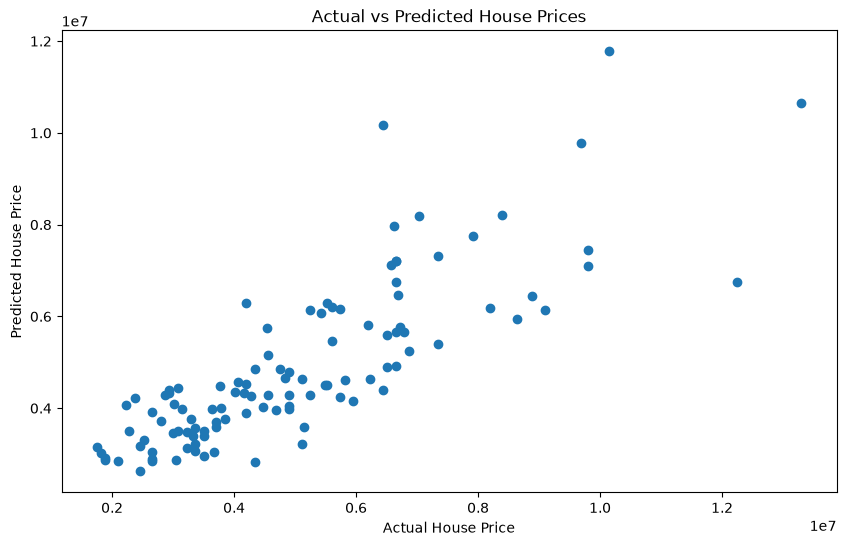

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_gb)

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

In [116]:
feature_importance = pd.Series(
    model_gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

area                               0.461708
bathrooms                          0.172952
airconditioning                    0.094350
parking                            0.048156
bedrooms                           0.045724
stories                            0.042845
basement                           0.031567
furnishingstatus_unfurnished       0.028457
prefarea                           0.025426
hotwaterheating                    0.016442
mainroad                           0.015577
guestroom                          0.015210
furnishingstatus_semi-furnished    0.001586
dtype: float64


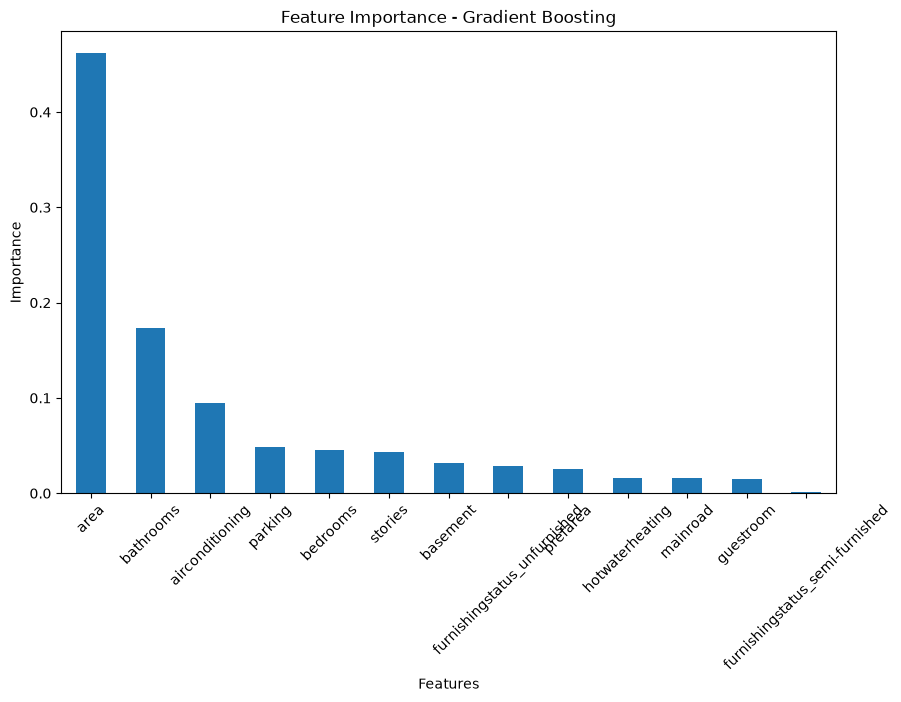

In [117]:
plt.figure(figsize=(10, 6))

feature_importance.plot(kind='bar')

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance - Gradient Boosting')

plt.xticks(rotation=45)
plt.show()

In [118]:
feature_importance = pd.Series(
    model_gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

area                               0.461708
bathrooms                          0.172952
airconditioning                    0.094350
parking                            0.048156
bedrooms                           0.045724
stories                            0.042845
basement                           0.031567
furnishingstatus_unfurnished       0.028457
prefarea                           0.025426
hotwaterheating                    0.016442
mainroad                           0.015577
guestroom                          0.015210
furnishingstatus_semi-furnished    0.001586
dtype: float64


Observation: Area is the most influential feature in predicting house prices, contributing approximately 46.17% of the model's feature importance.

Observation: Bathroom count is the second most important feature, indicating that the number of bathrooms contributes significantly to house price prediction.

Observation: Air conditioning has a notable contribution to price prediction, suggesting that this amenity is associated with higher-valued properties.

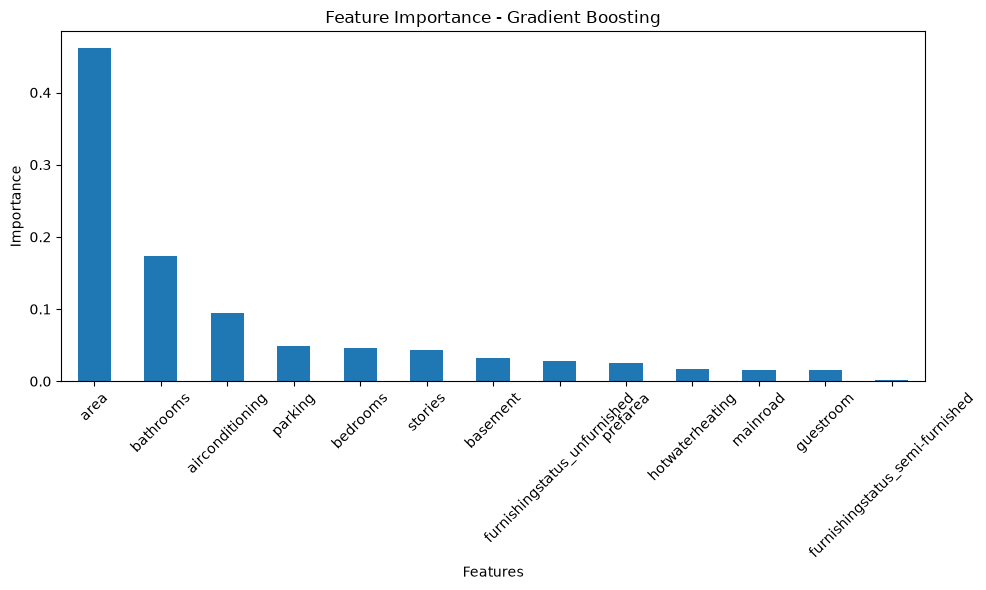

In [119]:
plt.figure(figsize=(10, 6))

feature_importance.plot(kind='bar')

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance - Gradient Boosting')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [120]:
import joblib

In [121]:
joblib.dump(model_gb, '../model/house_price_model.pkl')

['../model/house_price_model.pkl']

In [122]:
joblib.dump(X.columns.tolist(), '../model/feature_columns.pkl')

['../model/feature_columns.pkl']

In [123]:
import joblib

joblib.dump(model_gb, '../model/house_price_model.pkl')

joblib.dump(X.columns.tolist(), '../model/feature_columns.pkl')

['../model/feature_columns.pkl']

In [124]:
import os

print("Model exists:", os.path.exists('../model/house_price_model.pkl'))
print("Features exist:", os.path.exists('../model/feature_columns.pkl'))

Model exists: True
Features exist: True


In [125]:
import joblib

loaded_model = joblib.load('../model/house_price_model.pkl')
loaded_features = joblib.load('../model/feature_columns.pkl')

print("Model loaded successfully!")
print("Number of features:", len(loaded_features))

Model loaded successfully!
Number of features: 13


In [126]:
sample_house = X_test.iloc[[0]]

predicted_price = loaded_model.predict(sample_house)

print(f"Predicted Price: ₹{predicted_price[0]:,.2f}")
print(f"Actual Price: ₹{y_test.iloc[0]:,.2f}")

Predicted Price: ₹4,568,188.83
Actual Price: ₹4,060,000.00
